In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("cs1090a_hw1.ipynb")

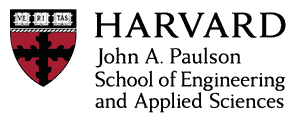

# CS1090A Introduction to Data Science
## Homework 1: A Reproducible Scraping & EDA Pipeline

**Harvard University**<br/>
**Fall 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, and Chris Gumb

<hr style="height:2.4pt">

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os
import json
import time
import glob
import datetime
from concurrent.futures import ThreadPoolExecutor
from IPython import display

In [3]:
# For calculating total notebook runtime
notebook_start = time.time()

In [4]:
style = '''<style>
h2, h3, h4 {
    background-color: #7efcf5;
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    padding: 0em;
    color: #1F2937;
}
h3 {
    background-color: #7efcf5;
    border-top: 5px solid #7ec4fc;
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    padding: 0.5em;
}
div.md {
    border-left: 5px solid #7ec4fc;
    border-right: 5px solid #7ec4fc;
    border-bottom: 5px solid #7ec4fc;
    padding: 0.5em;
}
div.prompt {
    background: #d1ffbd;
    border: thin solid black;
    border-radius: 2px;
    padding: 5px;
    margin: 0.5em 0;
    color: #1F2937;
}
/* A colour on the box does not reach <code> or <a> inside it. JupyterLab's dark
   theme gives inline code background-color: var(--jp-layout-color2) (#424242) and
   colours links #64b5f6, so setting only the box colour would put dark text on a
   dark code background. Code and links outside a box are left alone, where the
   theme's own pairing is already right. */
div.prompt code, div.alert code {
    background: rgba(0, 0, 0, 0.06);
    color: #1F2937;
}
div.prompt a, div.alert a {
    color: #1D4ED8;
}
</style>'''
display.display(display.HTML(style))


## Assignment Overview

You'll build a **reproducible data pipeline** around
[screenboston.com](https://screenboston.com), a site that aggregates movie
screenings from theaters around Boston. You will collect the data (live page +
historical snapshots), structure it with Pandas, enrich it from Wikipedia, use
EDA and visualization to understand it — and finish by making a **data-driven
recommendation** to the theaters themselves.

Think of the assignment is a structured mini-project. Each question tells
you the **goal**, the **required artifact** (file, variable, or figure), and any
**constraints** — how you get there is up to you. Sections 1–2 and the
supplemental notebooks (*MediaWiki API*, *Matplotlib & Seaborn reference*)
demonstrate every technique you'll need.

**The reproducibility theme.** A grader (or future you) should be able to re-run
your notebook and get the *same dataset and results*. Concretely, throughout
this assignment:

- **Guard every fetch** — code that touches the network must first check for a
  cached copy on disk and skip the request if it exists.
- **Derive results from pinned data** — that is, historical Wayback snapshots and cached
  files, not whatever the live web happens to say today.
- You will **submit your small data files** alongside the notebook (see
  Question 10), so your results are reproducible without the network.

**Structure** (10 questions + wrap-up; CS1090A graded out of 95, AC209A out of
100 — see the AC209A section):

1. Acquire the live page (4 pts)
2. Parse HTML into records (10 pts)
3. A reproducible dataset from Wayback snapshots (12 pts)
4. Build and clean a DataFrame (12 pts)
5. Exploratory data analysis (14 pts)
6. Resolve films to Wikipedia page IDs (8 pts)
7. Cache Wikipedia page content to disk (4 pts)
8. Enrich the data and ask a new question (10 pts)
9. **The decision: program Halloween weekend (14 pts)**
10. Reproducibility reflection & data submission (6 pts)
11. Wrap-up (1 pt)
12. **AC209A only:** SQL + concurrency (5 pts — required for AC209A; CS1090A
    students may skip this section entirely)

## Instructions

<div class="prompt" style="background: lightgreen; border: thin solid black; border-radius: 2px; padding: 5px; color: #1F2937;">

**General**
- To submit your notebook and data files, follow the instructions on the Canvas assignment page.
- **CS1090A is graded out of 95; AC209A is graded out of 100.** Three subquestions are marked *AC209A only*: 6a and 7a (concurrency evidence, 1 point each) and 8a (SQL, 3 points). CS1090A students skip those three and lose nothing by doing so — they are required work for AC209A, not extra credit for anyone.
- Plots must be legible and interpretable *without reading the code that generated them*: axis labels, a descriptive title, and a legend where appropriate.
- When asked to interpret a result, explain what it *means* — not what the plot looks like.
- The automated tests are **smoke tests only**: they check that required artifacts exist and have the right shape. Passing them is necessary, not sufficient — most credit is assigned by rubric to your approach, analysis, and writing.
- Your code must be **re-runnable — including offline**: "Restart Kernel and Run All Cells" must complete without error, and given your submitted data files it must complete *without any network access* (this is how it will be graded). 
- Only make network requests when the corresponding cache is empty. Gratuitous re-fetching (of pages you already saved) will lose credit.
- Feel free to add code or markdown cells. Include a written response wherever a question asks for one.
- **Before submitting: Restart Kernel and Run All Cells**, confirm no errors and that all output is visible.

**Use of AI tools**

AI tools — coding agents especially — are part of the modern data science workflow. One principle governs everything: **you are accountable for whatever you submit.** You must understand it, be able to communicate it, and be able to justify it.

- Written interpretations, the Question 9 memo, and the Question 10 reflection must be **your own reasoning in your own words**.
- In Question 10 you will briefly **disclose** how you used AI on this assignment and what you did to verify its output.
- Remember, any understanding you skip here will be paid for later in quizzes & midterms.
</div>

## Question 1: Acquire the live page

<p>Get the current HTML of <a href="https://screenboston.com">screenboston.com</a> and cache it to disk.</p>

<p><b>Why HTML at all?</b> Before scraping any site, look for structured data first — an official API, or the JSON many modern sites load their pages from. screenboston has one: <code>screenboston.com/__data.json</code> serves the current schedule as JSON, and parsing it would be easier than parsing HTML. We parse HTML anyway for one decisive reason: this assignment's dataset is <i>historical</i>, and the past only exists in the Wayback Machine's snapshots of the <i>rendered page</i>.</p>

<div class=prompt>

**Artifact:** the file <code>data/html/screenboston.html</code>.

**Constraints:**
- The fetch must be <b>guarded</b>: make an HTTP request only if the file does not already exist.
- <b>Identify yourself</b>: send a descriptive <code>User-Agent</code> naming the course. Some sites block anonymous default clients.
</div>

<p><b>Note what you just built:</b> this file is the one piece of your dataset that is <i>not</i> reproducible — it captures whatever the site showed on the day you ran this cell. (We'll fix that in Question 3)</p>

In [ ]:
HTML_DIR = "data/html"
LIVE_PAGE = os.path.join(HTML_DIR, "screenboston.html")

HEADERS = {
    "User-Agent": "CS1090A-HW1/2026 (Harvard CS1090A coursework; contact: sylvia_xing@fas.harvard.edu)"
}

os.makedirs(HTML_DIR, exist_ok = True)

if os.path.exists(LIVE_PAGE):
    print(f"Cache hit - {LIVE_PAGE} already on disk, no request made.")
else:
    response = requests.get("https://screenboston.com", headers = HEADERS, timeout = 30)
    response.raise_for_status()
    with open(LIVE_PAGE,"wb") as f:
        f.write(response.content)
    print(f"Fetched and cached {LIVE_PAGE}")

print (f"{os.path.getsize(LIVE_PAGE):,} bytes on disk")

Cache hit - data/html/screenboston.html already on disk, no request made.
257,049 bytes on disk


In [6]:
grader.check("q1")

q1 results: All test cases passed!

## Question 2: Parse the HTML into records

<p>Turn the page into structured data: one record per screening (a film, at a theater, on a date).</p>

<div class=prompt>

**Artifact:** a list of dictionaries named <code>movies</code>, one per screening, each with <i>exactly</i> these keys:

```python
{'title': 'Monty Python and the Holy Grail',
 'directors': 'Terry Jones, Terry Gilliam',   # plural key, even for one director
 'year': 1975,                                 # int
 'genre': 'Adventure',
 'runtime': '1h 31m',
 'theater': 'Coolidge Corner Theatre',
 'screen_date': '2026-07-11',
 'screen_times': '11:59 PM'}
```

**Constraints:**
- Write your parsing as <b>reusable function(s)</b> that take an HTML string — Question 3 will run them on ~20 more pages.
- Report how many records you extracted and display one example.
- Some listings are missing fields; a record with a <code>None</code> value is fine, but don't let one malformed listing crash the whole parse.
- <b>Never fail silently.</b> Your parser must also report how many listings it <i>failed</i> to parse. A page whose structure has drifted enough to break the parser should announce itself ("parsed 0 of 66 listings") — silent errors cause issues downstream and are a nightmare to debug.
</div>

**Hints:** your browser's *inspect* tool is how you learn the page's structure. Screening dates are not inside each listing — look at what *contains* the listings.

In [ ]:
META_RE = re.compile(r"^\s*(\d{4})\s*,\s*(.+?)\s*,\s*(\d+h(?:\s*\d+m)?|\d+m)\s*$")
DATE_RE = re.compile(r"^\d{4}-\d{2}-\d{2}$")
FIELDS = ("title", "directors", "year", "genre", "runtime",
          "theater", "screen_date", "screen_times")


def _fields_from_meta(rec, meta_p, pattern, has_year):
    g = pattern.match(meta_p.get_text(strip=True)).groups()
    rec["year"] = int(g[0]) if has_year else None
    rec["genre"], rec["runtime"] = g[1], g[2]

    directors_p = meta_p.find_previous_sibling("p")   
    rec["directors"] = directors_p.get_text(strip=True) if directors_p else None

    right = meta_p.parent.find_next_sibling("div")    
    if right is not None:
        theater_p = right.find("p", recursive=False)
        rec["theater"] = theater_p.get_text(strip=True) if theater_p else None
        times = [p.get_text(strip=True) for p in right.find_all("p")[1:]]
        rec["screen_times"] = ", ".join(t for t in times if t) or None


def parse_modern(card, snap_date=None):
    rec = dict.fromkeys(FIELDS)

    title_p = card.select_one("p.big")
    rec["title"] = title_p.get_text(strip=True) if title_p else None

    day = card.find_parent("div", id=DATE_RE)
    rec["screen_date"] = day["id"] if day else None

    meta_p = next((p for p in card.find_all("p")
                   if META_RE.match(p.get_text(strip=True))), None)
    if meta_p is not None:
        _fields_from_meta(rec, meta_p, META_RE, has_year=True)

    if rec["title"] is None and rec["year"] is None:
        raise ValueError("no title and no 'year, genre, runtime' line")
    return rec

LAYOUTS = [("modern", lambda soup: soup.select("button.text-left"), parse_modern)]

def parse_page(html, source="page", snap_date=None):
    soup = BeautifulSoup(html, "html.parser")

    for layout, find_cards, parse in LAYOUTS:
        cards = find_cards(soup)                 
        if cards:
            break
    else:
        print(f"{source}: FAILED -- no listing elements in any known layout; "
              f"the structure has drifted beyond the parser.")
        return [], 0

    records, failures = [], []
    for card in cards:
        try:
            records.append(parse(card, snap_date))
        except Exception as e:
            t = card.select_one("p.big")
            failures.append((t.get_text(strip=True) if t else "<no title>", e))

    print(f"{source}: parsed {len(records)} of {len(cards)} listings [{layout} layout]")
    for title, err in failures:
        print(f"  FAILED: {title!r} -- {err}")

    incomplete = {f: n for f in FIELDS if (n := sum(r[f] is None for r in records))}
    if incomplete:
        print(f"  incomplete fields among parsed records: {incomplete}")

    return records, len(failures)

with open(LIVE_PAGE, encoding="utf-8") as f:
    movies, n_failed = parse_page(f.read(), source="screenboston.html")

print(f"\n{len(movies)} records, {n_failed} failures. Example record:")
print(json.dumps(movies[0], indent=2))
print(json.dumps(movies[1], indent=2))

screenboston.html: parsed 104 of 104 listings [modern layout]

104 records, 0 failures. Example record:
{
  "title": "Hunt for the Wilderpeople",
  "directors": "Taika Waititi",
  "year": 2016,
  "genre": "Adventure",
  "runtime": "1h 41m",
  "theater": "The Brattle",
  "screen_date": "2026-09-20",
  "screen_times": "12:00 PM, 9:00 PM"
}
{
  "title": "For Heaven's Sake",
  "directors": "Sam Taylor",
  "year": 1926,
  "genre": "Comedy",
  "runtime": "0h 58m",
  "theater": "Somerville Theatre",
  "screen_date": "2026-09-20",
  "screen_times": "2:00 PM"
}


In [8]:
grader.check("q2")

q2 results: All test cases passed!

## Question 3: A reproducible dataset from Wayback snapshots

<p>The live page only shows the next couple of weeks. The Internet Archive's
<a href="https://archive.org/help/wayback_api.php">Wayback Machine availability API</a> lets you retrieve historical snapshots of the page — and because snapshots are <b>pinned</b>, a dataset built from them is reproducible.</p>

<div class=prompt>

**Artifacts:**
1. Snapshot HTML files saved as <code>data/html/snapshot_YYYYMMDD.html</code> — covering <b>all available snapshots</b> of screenboston.com <b>through September 8, 2026</b>.
2. <code>data/movies.json</code> — the combined list of screening records parsed from <i>every</i> HTML file in <code>data/html/</code> (snapshots + live page), written with the <code>json</code> module.

**Constraints:**
- Both steps must be <b>guarded</b> (i.e., check for existing cache before running) — and guard <b>per file</b>, so an interrupted run resumes instead of restarting (or worse, permanently locking in a partial download).
- <b>The archive spans a site redesign.</b> These snapshots run over two years, and
screenboston.com did not look the same throughout. At least one early snapshot will not
parse with selectors written for today's page. Your parser must <b>say so</b> rather than
quietly return an empty list — that is what "never fail silently" in Q2 was for.
<i>Extracting that page's listings anyway is optional and worth a bonus point</i>; be
warned that the older layout carries no release year at all, so <code>year</code> would
have to be <code>None</code> for those records.
- <b>Expect throttling and handle it.</b> The whole class hits archive.org the same week; you *will* see slow responses or HTTP 429. Check status codes before parsing or saving anything — a cached error page is worse than no cache (since a simple guard can't tell them apart). Sanity-check each saved snapshot (does it parse to a plausible number of listings?).
- Assume any well-formed page covers at least through the end of its snapshot month, and that a day's schedule doesn't change once displayed.
- Don't worry about duplicate screenings across overlapping snapshots — Question 4 deals with them.
- Report which snapshots you found and the total number of records.
</div>

**Hint:** the availability API returns the snapshot *closest* to a timestamp — probing one timestamp per month is a reasonable way to sweep the archive's history. Store your list in `movies` (it should now include records from all pages).

In [9]:
WAYBACK_API = "https://archive.org/wayback/available"
CUTOFF = "20260908"                       
SNAPSHOT_INDEX = "data/snapshot_index.json"


def count_listings(html):
    soup = BeautifulSoup(html, "html.parser")
    modern = soup.select("button.text-left")
    if modern:
        return len(modern), "modern"
    legacy = [a for a in soup.select("a") if a.select_one("p.big")]
    return len(legacy), "legacy"


def wayback_get(url, params=None, tries=6):
    for attempt in range(tries):
        try:
            r = requests.get(url, params=params, headers=HEADERS, timeout=60)
        except requests.RequestException as e:
            print(f"  {type(e).__name__} -- attempt {attempt + 1}/{tries}")
        else:
            if r.status_code == 200:
                return r
            print(f"  HTTP {r.status_code} -- attempt {attempt + 1}/{tries}")
        if attempt < tries - 1:
            time.sleep(5 * 2 ** attempt)          
    return None


def discover_snapshots():
    found = {}
    for year in (2024, 2025, 2026):
        for month in range(1, 13):
            probe = f"{year}{month:02d}15"
            if probe[:6] > CUTOFF[:6]:
                continue
            probe = min(probe, CUTOFF)
            r = wayback_get(WAYBACK_API, {"url": "screenboston.com", "timestamp": probe})
            if r is None:
                print(f"  probe {probe}: gave up")
                continue
            snap = r.json().get("archived_snapshots", {}).get("closest")
            if not (snap and snap.get("available")):
                continue
            ts = snap["timestamp"]                      
            if ts[:8] > CUTOFF:                         
                continue
            found[ts[:8]] = f"https://web.archive.org/web/{ts}id_/https://screenboston.com/"
            time.sleep(1)
    return found

if os.path.exists(SNAPSHOT_INDEX):
    with open(SNAPSHOT_INDEX) as f:
        snapshots = json.load(f)
    print(f"Cache hit: {len(snapshots)} snapshots in {SNAPSHOT_INDEX}, no API calls made.")
else:
    print("Probing the Wayback availability API, one timestamp per month...")
    snapshots = discover_snapshots()
    with open(SNAPSHOT_INDEX, "w") as f:
        json.dump(snapshots, f, indent=1)
    print(f"Found {len(snapshots)} distinct snapshots through {CUTOFF}.")

covered = {os.path.basename(p)[9:15] for p in glob.glob("data/html/snapshot_*.html")}

for date8 in sorted(snapshots):
    path = f"data/html/snapshot_{date8}.html"
    if os.path.exists(path):
        print(f"  snapshot_{date8}.html: already cached")
        continue
    if date8[:6] in covered:
        print(f"  snapshot_{date8}.html: skipped, {date8[:6]} already covered")
        continue
    covered.add(date8[:6])

    r = wayback_get(snapshots[date8])
    if r is None:                                   
        print(f"  {date8}: FAILED after retries -- not saved; re-run to retry")
        continue

    n, layout = count_listings(r.text)
    if n == 0:
        print(f"  {date8}: 0 listings -- NOT saved (looks like an error/redirect page)")
        continue

    with open(path, "wb") as f:
        f.write(r.content)
    print(f"  snapshot_{date8}.html: saved, {len(r.content):,} bytes, "
          f"{n} listings [{layout}]")
    time.sleep(1)

print(f"\n{len(glob.glob('data/html/snapshot_*.html'))} snapshot files on disk.")


Cache hit: 24 snapshots in data/snapshot_index.json, no API calls made.
  snapshot_20240328.html: already cached
  snapshot_20240524.html: already cached
  snapshot_20240912.html: skipped, 202409 already covered
  snapshot_20241006.html: already cached
  snapshot_20241119.html: skipped, 202411 already covered
  snapshot_20241216.html: skipped, 202412 already covered
  snapshot_20250116.html: skipped, 202501 already covered
  snapshot_20250217.html: already cached
  snapshot_20250326.html: already cached
  snapshot_20250416.html: skipped, 202504 already covered
  snapshot_20250616.html: already cached
  snapshot_20250622.html: already cached
  snapshot_20250813.html: already cached
  snapshot_20250918.html: skipped, 202509 already covered
  snapshot_20251119.html: skipped, 202511 already covered
  snapshot_20260123.html: already cached
  snapshot_20260214.html: already cached
  snapshot_20260312.html: already cached
  snapshot_20260413.html: already cached
  snapshot_20260513.html: alre

In [10]:
LEGACY_RE = re.compile(r"^\s*([^,]+?)\s*,\s*(.+?)\s*,\s*(\d+h(?:\s*\d+m)?|\d+m)\s*$")
DAY_RE    = re.compile(r"^[A-Z][a-z]{2}\s+([A-Z][a-z]{2})\s+(\d{1,2})$")
SNAP_RE   = re.compile(r"^snapshot_(\d{8})\.html$")

def parse_legacy(card, snap_date):
    rec = dict.fromkeys(FIELDS)
    title_p = card.select_one("p.big")
    rec["title"] = title_p.get_text(strip=True) if title_p else None

    block, head = card.parent, None
    while block is not None and block.name != "body" and head is None:
        head = next((p for p in block.find_all("p")
                     if DAY_RE.match(p.get_text(strip=True))), None)
        if head is None:
            block = block.parent

    if head is not None and snap_date is not None:
        mon, dayn = DAY_RE.match(head.get_text(strip=True)).groups()
        m = datetime.datetime.strptime(mon, "%b").month
        y = snap_date.year + (1 if m < snap_date.month else 0)
        rec["screen_date"] = f"{y}-{m:02d}-{int(dayn):02d}"

    meta_p = next((p for p in card.find_all("p")
                   if LEGACY_RE.match(p.get_text(strip=True))), None)
    if meta_p is not None:
        _fields_from_meta(rec, meta_p, LEGACY_RE, has_year=False)
    if rec["title"] is None and rec["screen_date"] is None:
        raise ValueError("no title and no usable date heading")
    return rec

LAYOUTS.append(("legacy",
                lambda soup: [a for a in soup.select("a") if a.select_one("p.big")],
                parse_legacy))

def snapshot_date(path):
    name = os.path.basename(path)
    m = SNAP_RE.match(name)
    if m:
        return datetime.datetime.strptime(m.group(1), "%Y%m%d").date()
    if name == os.path.basename(LIVE_PAGE):
        return None
    raise ValueError(f"unexpected file in data/html/: {name!r}")


movies, total_failed = [], 0
for path in sorted(glob.glob("data/html/*.html")):
    with open(path, encoding="utf-8") as f:
        recs, nf = parse_page(f.read(), os.path.basename(path), snapshot_date(path))
    movies.extend(recs)
    total_failed += nf

with open("data/movies.json", "w") as f:
    json.dump(movies, f, indent=1)

print(f"\n{len(movies)} records from {len(glob.glob('data/html/*.html'))} HTML files, "
      f"{total_failed} listings failed. Wrote data/movies.json.")

screenboston.html: parsed 104 of 104 listings [modern layout]
snapshot_20240328.html: parsed 2 of 2 listings [legacy layout]
  incomplete fields among parsed records: {'year': 2}
snapshot_20240524.html: parsed 118 of 118 listings [modern layout]
snapshot_20240621.html: parsed 67 of 67 listings [modern layout]
snapshot_20240803.html: parsed 105 of 105 listings [modern layout]
snapshot_20240904.html: parsed 113 of 113 listings [modern layout]
snapshot_20240926.html: parsed 168 of 168 listings [modern layout]
  incomplete fields among parsed records: {'directors': 2, 'year': 2, 'genre': 2, 'runtime': 2, 'theater': 2, 'screen_times': 2}
snapshot_20241006.html: parsed 138 of 138 listings [modern layout]
snapshot_20241101.html: parsed 95 of 95 listings [modern layout]
snapshot_20241206.html: parsed 62 of 62 listings [modern layout]
snapshot_20250105.html: parsed 74 of 74 listings [modern layout]
snapshot_20250131.html: parsed 116 of 116 listings [modern layout]
  incomplete fields among pars

In [11]:
print("Snapshots on disk:")
print(sorted(os.path.basename(f) for f in glob.glob('data/html/snapshot_*')))
print(f"{len(movies)} total screening records across all HTML files.")

Snapshots on disk:
['snapshot_20240328.html', 'snapshot_20240524.html', 'snapshot_20240621.html', 'snapshot_20240803.html', 'snapshot_20240904.html', 'snapshot_20240926.html', 'snapshot_20241006.html', 'snapshot_20241101.html', 'snapshot_20241206.html', 'snapshot_20250105.html', 'snapshot_20250131.html', 'snapshot_20250217.html', 'snapshot_20250326.html', 'snapshot_20250428.html', 'snapshot_20250616.html', 'snapshot_20250622.html', 'snapshot_20250813.html', 'snapshot_20250903.html', 'snapshot_20250924.html', 'snapshot_20251021.html', 'snapshot_20251127.html', 'snapshot_20251215.html', 'snapshot_20260123.html', 'snapshot_20260214.html', 'snapshot_20260312.html', 'snapshot_20260413.html', 'snapshot_20260513.html', 'snapshot_20260616.html', 'snapshot_20260708.html', 'snapshot_20260827.html', 'snapshot_20260908.html']
2836 total screening records across all HTML files.


In [12]:
grader.check("q3")

q3 results: All test cases passed!

## Question 4: Build and clean a DataFrame

<div class=prompt>

**Artifact:** a DataFrame <code>df</code> built from <code>data/movies.json</code>, satisfying:

1. **No duplicate rows** (rows where *all* values match — overlapping snapshots create many). Report how many rows you dropped and how many remain.
2. A **missingness audit**: NaN counts per column, and a display of the rows containing at least one NaN (or confirmation there are none).
3. **A dtype on each column that matches what the column holds**: <code>screen_date</code> as a datetime type, <code>runtime</code> as a timedelta type.
4. Sorted by ascending <code>screen_date</code>.

<b>Verify as you go</b> — after each transform, check what you actually produced (<code>.shape</code>, <code>.dtypes</code>, a spot-check of rows). Whether you or an 'assistant' wrote the code, the sign-off on the result is your responsibility.

Then use the clean frame to create:

5. A table of **screenings per theater per calendar month** (rows = month, columns = theater; restrict columns to the 6 busiest theaters). Then, in one or two sentences: what do you notice?
</div>

In [13]:
with open("data/movies.json") as f:
    df = pd.DataFrame(json.load(f))
print(f"Loaded {df.shape[0]} records from data/movies.json with {df.shape[1]} columns.")

before = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped {before - df.shape[0]} duplicate rows; {df.shape[0]} unique screenings remain.")

TEXT_COLS = ["title", "directors", "genre", "theater", "screen_times"]
df[TEXT_COLS] = df[TEXT_COLS].astype("string")
df["year"] = df["year"].astype("Int64")          
df["screen_date"] = pd.to_datetime(df["screen_date"], format="%Y-%m-%d")

_rt = df["runtime"].str.extract(r"^(?:(\d+)h)?\s*(?:(\d+)m)?$")
_minutes = _rt[0].astype("Float64").fillna(0) * 60 + _rt[1].astype("Float64").fillna(0)
_unconverted = int((df["runtime"].notna() & _minutes.isna()).sum())
print(f"Runtime strings that failed to convert: {_unconverted}")   
df["runtime"] = pd.to_timedelta(_minutes.where(df["runtime"].notna()), unit="m")

df = df.sort_values("screen_date", kind="stable").reset_index(drop=True)

print("\nDtypes:")
print(df.dtypes)

print("\nNaN count per column:")
print(df.isna().sum())

nan_rows = df[df.isna().any(axis=1)]
if nan_rows.empty:
    print("\nNo rows contain missing values.")
else:
    print(f"\n{len(nan_rows)} rows contain at least one NaN:")

    print(nan_rows.to_string())

Loaded 2836 records from data/movies.json with 8 columns.
Dropped 436 duplicate rows; 2400 unique screenings remain.
Runtime strings that failed to convert: 0

Dtypes:
title                   string
directors               string
year                     Int64
genre                   string
runtime         timedelta64[s]
theater                 string
screen_date     datetime64[us]
screen_times            string
dtype: object

NaN count per column:
title            0
directors        8
year            10
genre            8
runtime          8
theater          8
screen_date      0
screen_times     8
dtype: int64

10 rows contain at least one NaN:
                                                                  title         directors  year     genre         runtime              theater screen_date screen_times
0                                                            Blue Giant  Yuzuru Tachikawa  <NA>  Thriller 0 days 02:00:00  Museum of Fine Arts  2024-03-30      7:00 PM
1          

In [14]:
top6 = df["theater"].value_counts().head(6).index

monthly = (
    df.assign(month=df["screen_date"].dt.to_period("M"))
      .groupby(["month", "theater"], observed=True)
      .size()
      .unstack(fill_value=0)
      .reindex(columns=top6)          
)

all_months = pd.period_range(df["screen_date"].min(), df["screen_date"].max(), freq="M")
monthly = monthly.reindex(all_months)         
monthly.index.name = "month"

_impossible = df["year"] > df["screen_date"].dt.year.max()
df.loc[_impossible, "year"] = pd.NA

print("Screenings per theater per calendar month (6 busiest theaters)")
print(monthly.to_string())

print("\nTotal screenings per theater:")
print(monthly.sum().astype(int).to_string())


Screenings per theater per calendar month (6 busiest theaters)
theater  The Brattle  Coolidge Corner Theatre  Harvard Film Archive  Somerville Theatre  West Newton Cinema  Museum of Fine Arts
month                                                                                                                           
2024-03            0                        0                     0                   0                   0                    1
2024-04            0                        0                     0                   0                   0                    1
2024-05           18                        8                     0                   3                   0                    3
2024-06           50                       24                     0                  10                   1                    9
2024-07            6                       24                     0                   1                   0                    0
2024-08           43              

The Brattle and Coolidge Corner Theatre have the highest screening counts across most months, while the other theaters show fewer screenings and more variation. Some months are missing because no Wayback snapshot covered those periods.


In [15]:
grader.check("q4")

q4 results: All test cases passed!

## Question 5: Exploratory data analysis

Every visualization needs: labeled axes, descriptive title, and a written interpretation of what it *means*.
These are relatively simple visualizations. You should really try writing them yourself.

(Note: "Screening" refers to one row of the `df`.)

### 5.1 Longest films

Display the 10 longest reported runtimes (rows, descending).

Then, in one or two sentences: what are these longest entries, and what does that tell you about what the `runtime` column is measuring?

In [16]:
longest = df.sort_values("runtime", ascending=False).head(10)
longest[["title", "year", "genre", "runtime", "theater", "screen_date"]]

,title,year,genre,runtime,theater,screen_date
1787,51st Annual Boston Science Fiction Film Marathon,2026,SciFi,1 days 00:00:00,Somerville Theatre,2026-02-15
864,Boston Sci-Fi Film Festival Marathon,2025,SciFi,1 days 00:00:00,Somerville Theatre,2025-02-16
2259,Marathon '77,1977,Drama,0 days 13:00:00,Harvard Film Archive,2026-09-12
1030,The Lord of the Rings Trilogy,2001,Fantasy,0 days 12:45:00,Coolidge Corner Theatre,2025-05-04
1886,The Lord of the Rings Trilogy,2001,Family,0 days 12:45:00,Coolidge Corner Theatre,2026-03-22
1909,The Lord of the Rings Trilogy,2001,Fantasy,0 days 12:45:00,Coolidge Corner Theatre,2026-03-29
532,23rd Halloween Horror Marathon,2024,Horror,0 days 12:00:00,Coolidge Corner Theatre,2024-10-26
1506,24th Halloween Horror Marathon,2025,Horror,0 days 12:00:00,Coolidge Corner Theatre,2025-10-25
1564,GODZILLATHON,1954,Horror,0 days 11:40:00,Somerville Theatre,2025-11-08
1962,Satantango,1994,Drama,0 days 07:12:00,Harvard Film Archive,2026-04-25


These top entries are marathons/serials/multi-part epics. The column is per-listing, so it measures the length of the programmed event, not the film's canonical runtime.

### 5.2 Screening counts

Side-by-side subplots with a shared y-axis: screenings by theater, and screenings by genre.

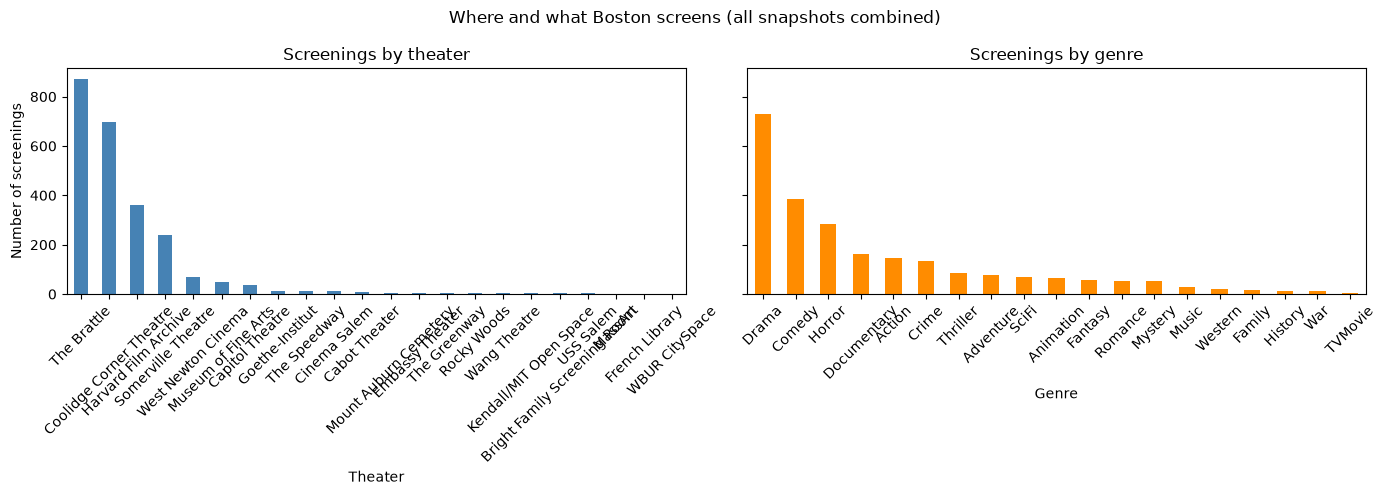

In [17]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df["theater"].value_counts().plot(
    kind="bar",
    color="steelblue",
    title="Screenings by theater",
    xlabel="Theater",
    ylabel="Number of screenings",
    rot=45,
)

plt.subplot(1, 2, 2, sharey=plt.gca())
df["genre"].value_counts().plot(
    kind="bar",
    color="darkorange",
    title="Screenings by genre",
    xlabel="Genre",
    rot=45,
)

plt.suptitle("Where and what Boston screens (all snapshots combined)")
plt.tight_layout()

### 5.3 Film vintage

A pair of plots showing the distribution of release `year`, overall and broken out by theater (your choice of plot types, but justify the choice).

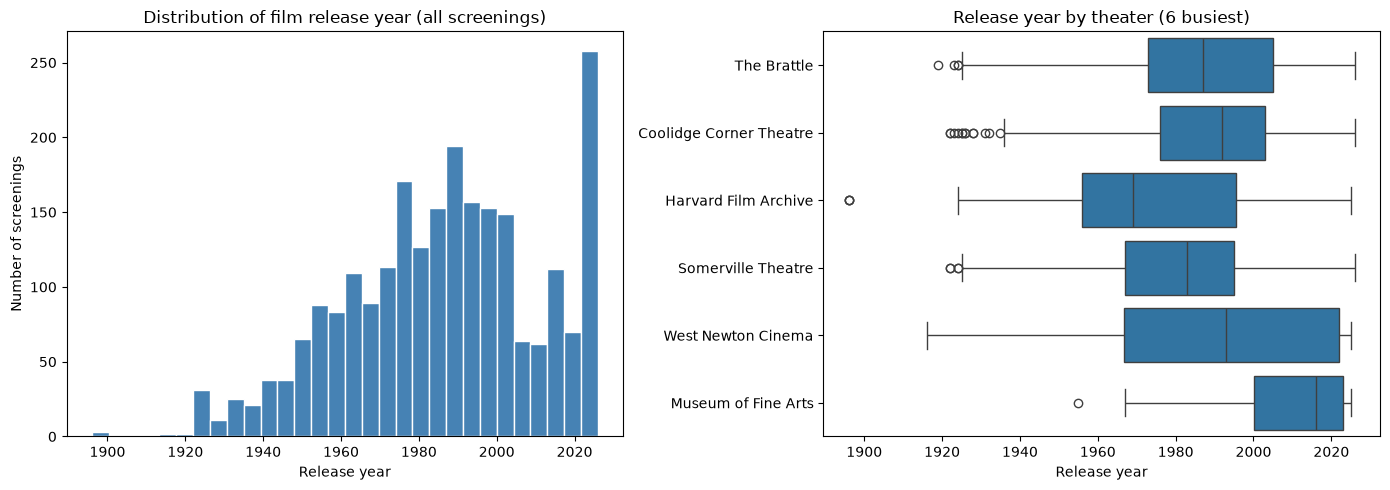

In [18]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df["year"].dropna(), bins=30, color="steelblue", edgecolor="white")
plt.title("Distribution of film release year (all screenings)")
plt.xlabel("Release year")
plt.ylabel("Number of screenings")

plt.subplot(1, 2, 2)
sns.boxplot(
    data=df[df["theater"].isin(top6)],
    x="year",
    y="theater",
    order=top6
)
plt.title("Release year by theater (6 busiest)")
plt.xlabel("Release year")
plt.ylabel("")

plt.tight_layout()
plt.show()

The overall distribution gets a histogram because the shape is
the finding, while a single summary statistic would hide it. The second comparison gets
horizontal boxplots because six theaters' medians, spreads and outliers fit on one
shared year axis, and long theater names read cleanly on the y-axis.

The median release year is 1988 and 69.6% of screenings are of pre-2000 films, so these venues are running a repertory business. The histogram has a broad peak across the 1970s–90s, a trough in the 2000s–2010s, and a sharp rebound in the 2020s.  

The by-theater panel shows these venues are not interchangeable. Harvard Film Archive is
the archival extreme, the Museum of Fine Arts sits at the opposite end. The Brattle, Coolidge and Somerville cluster together with medians in the late 1980s–early 1990s and wide interquartile
ranges, meaning they mix current releases with revivals rather than specializing.


### 5.4 One custom question

Pose a question of your own about the screening data and answer it with an appropriate plot whose *type differs* from those you used above. State the question, your approach, the plot, and your interpretation.

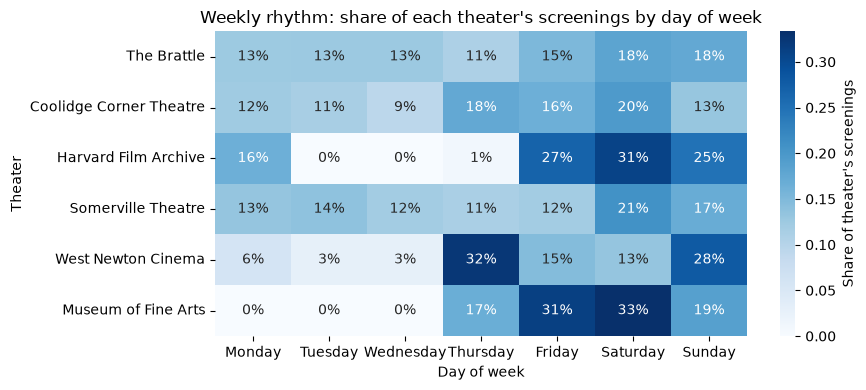

In [19]:
df["weekday"] = df["screen_date"].dt.day_name()
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

counts = (df[df["theater"].isin(top6)]
          .pivot_table(index="theater", columns="weekday",
                       values="title", aggfunc="count")
          .reindex(index=top6, columns=days)
          .fillna(0))

shares = counts.div(counts.sum(axis=1), axis=0)

plt.figure(figsize=(9, 4))
sns.heatmap(
    shares,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    cbar_kws={"label": "Share of theater's screenings"}
)

plt.title("Weekly rhythm: share of each theater's screenings by day of week")
plt.xlabel("Day of week")
plt.ylabel("Theater")
plt.tight_layout()
plt.show()


**Question**: does each theater have a characteristic day of the week?

**Approach:** I derived the weekday from `screen_date`, cross-tabulated theater ×
weekday for the six busiest theaters, and row-normalized so that each row is that
theater's share of screenings. I used a heatmap because the finding where two-dimensional structure reads better than 42 bars.

The Brattle runs an almost flat week as it operates as a daily cinema whose audience is assumed to be available any evening. Harvard Film Archive has 0.0% of its screenings fall on Tuesday, 0.3% on Wednesday, 1.0% on Thursday, and 81.7% land Friday–Sunday. The Museum of Fine Arts is similar. These are weekend-only programs attached to an institution whose main business is something else, and whose audience travels to a specific event rather than dropping in. West Newton Cinema, however, has 33.9% of its screenings on Thursday, nearly triple any other venue's Thursday share. 


### 5.5 Critique a chart

The provided cell below draws a chart from *your* data, exactly as an over-eager assistant might. It runs without error and looks polished. In a short written answer: what claim does it make, in what specific ways is it misleading, and how would you redraw it so that the visual comparison matches the numbers? (This is the skill the whole module turns on: the tools can draw anything; *you* sign off on what a chart says.)

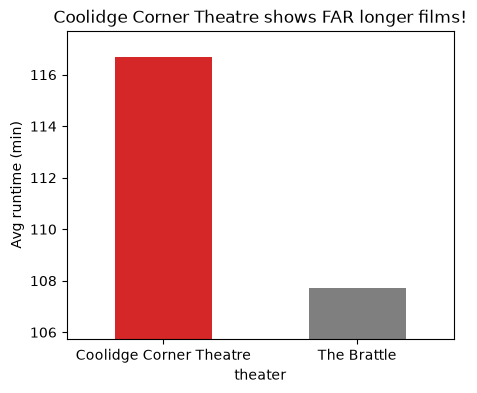

Means: {'Coolidge Corner Theatre': 116.7, 'The Brattle': 107.7}


In [20]:
# --- 5. PROVIDED CELL: do not edit. Critique the chart this draws. ----------
_rt = df.dropna(subset=["runtime"]).copy()
_rt["runtime_min"] = _rt["runtime"].dt.total_seconds() / 60
_top2 = _rt["theater"].value_counts().head(2).index
_means = _rt[_rt["theater"].isin(_top2)].groupby("theater")["runtime_min"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
_means.plot(kind="bar", ax=ax, color=["C3", "C7"], rot=0)
ax.set_ylim(_means.min() - 2, _means.max() + 1)   # <- look closely
ax.set_ylabel("Avg runtime (min)")
ax.set_title(f"{_means.idxmax()} shows FAR longer films!")
plt.show()
print("Means:", _means.round(1).to_dict())

The claim is that Coolidge Corner Theatre shows FAR longer films than The Brattle, and the bars make the difference look like roughly a factor of several.

The chart is misleading because the y-axis is truncated, making the difference between Coolidge Corner Theatre and The Brattle look much larger than it really is. Their average runtimes differ by only about 9 minutes.
The mean is also affected by unusually long events such as movie marathons, so it does not fully represent a typical screening. A better version would start the y-axis at 0 or use a boxplot to show the full runtime distribution.

I will redraw it by baseline the y-axis at zero and put all six major theaters on it. Replace the two bars with boxplots (or a strip plot over the bars) so the reader sees the distributions rather than two points — that alone makes the overlap obvious. Report medians alongside means, or exclude the marathon events explicitly and say so in a caption. Finally, retitle to the actual finding: "Median runtime is within one minute cross Boston's two busiest repertory theaters." 



## Question 6: Resolve films to Wikipedia page IDs

<p>To enrich our data we need a <b>stable identifier</b> for each film's Wikipedia article. Query the <a href="https://www.mediawiki.org/wiki/API:Main_page">MediaWiki API</a> directly with <code>requests</code> — the numeric <code>pageid</code> is permanent even when article titles change. The <i>MediaWiki API</i> supplemental notebook walks through everything you need.</p>

<div class=prompt>

**Artifact:** a <code>wiki_id</code> column on <code>df</code> (the film's numeric pageid, or <code>NaN</code> when you can't resolve one confidently).

**Constraints:**
- Query each <b>unique film</b> once — not once per screening row.
- Cache your resolved IDs to disk (e.g. a CSV) so re-runs make <b>zero</b> lookup requests.
- Be polite: identify yourself with a User-Agent and handle rate-limiting (HTTP 429 / <code>maxlag</code>) gracefully. Sustained one-search-per-film traffic <i>will</i> get you throttled — plan your request budget.
- Report your coverage (share of screenings with a resolved ID) and show a few films you failed to match — what, if anything, do the misses have in common?

**AC209A (required; CS1090A optional):** parallelize whatever per-film requests remain with a small thread pool (max ~4 workers).
</div>

**Hint (request budget):** film articles follow strong title conventions — <i>"Title (YEAR film)"</i>, <i>"Title (film)"</i>, or just <i>"Title"</i>. The API's <code>action=query&titles=a|b|c</code> form checks up to <b>50 exact titles per request</b> (add <code>redirects=1</code>), which resolves most films in a handful of requests; full-text <code>search</code> is then only needed as a fallback for the stragglers. See the MediaWiki supplemental notebook.

In [21]:
WIKI_API = "https://en.wikipedia.org/w/api.php"
WIKI_IDS_CSV = "data/wiki_ids.csv"
BATCH = 50

session = requests.Session()          
session.headers.update(HEADERS)       

def wiki_get(params):
    params = {**params, "format": "json", "formatversion": 2, "maxlag": 5}
    for attempt in range(5):
        r = session.get(WIKI_API, params=params, timeout=30)
        if r.status_code == 200:
            data = r.json()
            if "error" not in data:      
                return data
            print(f"  API error: {data['error']['code']} -- attempt {attempt + 1}/5")
        else:
            print(f"  HTTP {r.status_code} -- attempt {attempt + 1}/5")
        time.sleep(2 ** attempt)
    return None


def resolve_exact(titles):
    data = wiki_get({"action": "query", "titles": "|".join(titles), "redirects": 1,
                     "prop": "pageprops", "ppprop": "disambiguation"})
    if data is None:
        return {}
    q = data["query"]
    hop = {h["from"]: h["to"] for h in q.get("normalized", []) + q.get("redirects", [])}
    pageid = {p["title"]: p["pageid"] for p in q["pages"]
              if "missing" not in p and "disambiguation" not in p.get("pageprops", {})}

    out = {}
    for t in titles:
        final = t
        for _ in range(3):              
            final = hop.get(final, final)
        if final in pageid:
            out[t] = pageid[final]
    return out

def resolve_batched(candidates, workers=4):
    keys = list(candidates)
    batches = [keys[i:i + BATCH] for i in range(0, len(keys), BATCH)]
    with ThreadPoolExecutor(max_workers=workers) as pool:
        results = pool.map(lambda b: resolve_exact([candidates[k] for k in b]), batches)
        return {k: hits[candidates[k]]
                for b, hits in zip(batches, results) for k in b if candidates[k] in hits}

def search_one(title, year):
    query = f"{title} {int(year)} film" if pd.notna(year) else f"{title} film"
    data = wiki_get({"action": "query", "list": "search", "srsearch": query, "srlimit": 1})
    hits = data["query"]["search"] if data else []
    return hits[0]["pageid"] if hits else None

def keep_films(pageids, chunk=50):
    ok = set()
    for i in range(0, len(pageids), chunk):
        data = wiki_get({"action": "query", "pageids": "|".join(map(str, pageids[i:i + chunk])),
                         "prop": "revisions", "rvprop": "content", "rvslots": "main",
                         "rvsection": 0})
        for p in (data or {}).get("query", {}).get("pages", []):
            lead = p.get("revisions", [{}])[0].get("slots", {}).get("main", {}).get("content", "")
            if re.search(r"\{\{\s*Infobox film", lead, re.I):
                ok.add(p["pageid"])
    return ok

In [22]:
df["film_key"] = df["title"].str.strip() + "||" + df["year"].astype("Int64").astype(str)
films = df.drop_duplicates("film_key")[["film_key", "title", "year"]]

COLS = ["film_key", "title", "year", "wiki_id", "method"]
if os.path.exists(WIKI_IDS_CSV):
    cache = pd.read_csv(WIKI_IDS_CSV).astype({"wiki_id": "Int64"})
else:
    cache = pd.DataFrame(columns=COLS).astype({"wiki_id": "Int64"})

pending = {r.film_key: (r.title, r.year)
           for r in films[~films["film_key"].isin(cache["film_key"])].itertuples()}
print(f"{len(films)} unique films; {len(cache)} already cached, {len(pending)} to look up.")

LADDER = [("Title (YEAR film)", lambda t, y: f"{t} ({int(y)} film)" if pd.notna(y) else None),
          ("Title (film)",      lambda t, y: f"{t} (film)"),
          ("Title",             lambda t, y: t)]

t0, resolved = time.time(), {}
for label, make_title in LADDER:
    if not pending:
        break
    cands = {k: make_title(t, y) for k, (t, y) in pending.items()}
    cands = {k: v for k, v in cands.items() if v}
    hits = resolve_batched(cands)
    for k, pid in hits.items():
        resolved[k] = (pid, label)
        pending.pop(k)
    print(f"{label:20s} {len(hits):4d} resolved in {-(-len(cands) // BATCH)} requests; "
          f"{len(pending)} still unresolved")

if pending:                                    
    keys = list(pending)
    with ThreadPoolExecutor(max_workers=4) as pool:
        for k, pid in zip(keys, pool.map(lambda k: search_one(*pending[k]), keys)):
            if pid:
                resolved[k] = (pid, "search")
                pending.pop(k)
    print(f"{'search fallback':20s} {len(keys) - len(pending):4d} resolved in {len(keys)} requests")

elapsed = time.time() - t0

confirmed = keep_films(sorted({pid for pid, _ in resolved.values()}))
info = films.set_index("film_key")[["title", "year"]].apply(tuple, axis=1)
for k in [k for k, (pid, _) in resolved.items() if pid not in confirmed]:
    del resolved[k]; pending[k] = info[k]
print(f"{'infobox filter':20s} {len(pending):4d} unconfirmed -> NaN, {len(resolved)} confirmed")

new = pd.DataFrame(
    [{"film_key": k, "title": t, "year": y,
      "wiki_id": resolved.get(k, (pd.NA, None))[0], "method": resolved.get(k, (None, "unresolved"))[1]}
     for k, (t, y) in {**{k: v for k, v in films.set_index("film_key")[["title", "year"]]
                          .apply(tuple, axis=1).items() if k in resolved}, **pending}.items()],
    columns=COLS)

if len(new):
    cache = pd.concat([cache, new], ignore_index=True).astype({"wiki_id": "Int64"})
    cache.to_csv(WIKI_IDS_CSV, index=False)
    print(f"\nLooked up {len(new)} films in {elapsed:.1f}s; cache now {len(cache)} rows.")

df["wiki_id"] = df["film_key"].map(cache.set_index("film_key")["wiki_id"])


print(f"Coverage: {df['wiki_id'].notna().mean():.1%} of {len(df)} screenings, "
      f"{cache['wiki_id'].notna().mean():.1%} of {len(cache)} unique films")
print(cache["method"].value_counts())
print(cache[cache["wiki_id"].isna()][["title", "year"]].head(20))


1720 unique films; 1720 already cached, 0 to look up.
infobox filter          0 unconfirmed -> NaN, 0 confirmed
Coverage: 91.6% of 2400 screenings, 90.8% of 1720 unique films
method
Title                620
Title (YEAR film)    501
Title (film)         382
unresolved           158
search                59
Name: count, dtype: int64
                                                  title    year
1562                     RPM Fest Presents: Karel Doing  1998.0
1563                        Boston Punk Unbound/Rewound  1976.0
1564   Futility in Frames: The Hypnoses of Vlatko Gilic  1968.0
1565                           Maso and Miso Go Boating  1976.0
1566     Sanggyedong Olympic / Graeae: A Stationed Idea  1988.0
1567                Labor News No. 1 / melting icecream  1989.0
1568  RPM Fest Presents Mountains Meet the Sea: Kath...  2007.0
1569      RPM Presents: Time, a Substance: Janie Geiser  2020.0
1570  Document of Collision: The Whiplashed Ones (Do...  1969.0
1571  The Ecstatic Square: 

1,562 of 1,720 unique films have a `wiki_id` (90.8%), covering 91.6% of the
2,400 screenings. Budget: 290 requests in 62.0 s — 77 batched title lookups, 179 searches,
34 verification requests.

25 matched nothing, the displayed string is not a film title. 133 matched the wrong entity titles that are ordinary words or shared names: "Revenge" → the concept, "High School" → secondary education, "Essene" → the sect, "Aladdin" → the folk tale, "The Conformist" (listed as 1971, the article is the 1970 film) → Moravia's novel. 



In [23]:
grader.check("q6")

q6 results: All test cases passed!

### 6a. Concurrency evidence — AC209A only (1 pt)

Question 6 required you to parallelise the per-film requests with a small thread pool. Point to where you did that, and show evidence it worked: either a timing comparison, or the batch and worker structure together with a measured runtime. One code or markdown cell is enough. Section 1's Appendix A11 covers the pattern, and the *MediaWiki API* supplemental shows the batched request this runs on top of.

Parallelization happens in `resolve_batched()`. Candidate titles are chunked into batches of `BATCH = 50` and submitted to `ThreadPoolExecutor(max_workers=4)`. The full uncached run took ~62s, about 4.7 requests/second including retry backoff from 36 throttled search attempts. 


## Question 7: Cache Wikipedia page content to disk

<p>Acquire each resolved film's article content — <b>to disk, not into your DataFrame</b>. A DataFrame column of full pages bloats every downstream save to hundreds of megabytes; a directory of files keyed by <code>pageid</code> costs one lookup and makes the pipeline resumable.</p>

<p><b>Request budget, again — and harder.</b> Fetching ~1,300 rendered pages one-per-request (<code>action=parse</code>) triggers Wikipedia's throttling under sustained load. Instead, fetch each page's <b>wikitext source</b> via <code>action=query&amp;prop=revisions&amp;rvprop=content&amp;rvslots=main</code>, which accepts <b>50 <code>pageids</code> per request</b>; that's your whole cache in a couple dozen calls! The infobox data you'll need in Question 8 is present in the source (e.g. <code>| language = [[English language|English]]</code>).</p>

<div class=prompt>

**Artifact:** one file <code>data/wiki/&lt;pageid&gt;.txt</code> (wikitext) per resolved film.

**Constraints:**
- Guarded: request only pages not already cached, so a re-run when every page is already saved makes zero requests.
- Use the batched endpoint — one-request-per-page acquisition will lose credit.
- Report how many pages you cached and the total size on disk.

**AC209A (required; CS1090A optional):** issue the batch requests concurrently (2–3 workers over the chunk list).
</div>

In [24]:
WIKI_DIR = "data/wiki"
os.makedirs(WIKI_DIR, exist_ok=True)

page_path = lambda pid: os.path.join(WIKI_DIR, f"{pid}.txt")

ids = sorted(df["wiki_id"].dropna().astype(int).unique())
missing = [i for i in ids if not os.path.exists(page_path(i))]
print(f"{len(ids)} resolved films: {len(ids) - len(missing)} already cached, {len(missing)} to fetch.")


def fetch_chunk(pageids):
    data = wiki_get({"action": "query", "pageids": "|".join(map(str, pageids)),
                     "prop": "revisions", "rvprop": "content", "rvslots": "main"})
    if data is None:
        return 0
    saved = 0
    for p in data["query"]["pages"]:
        if "missing" in p:
            continue
        text = p["revisions"][0]["slots"]["main"]["content"]
        with open(page_path(p["pageid"]), "w", encoding="utf-8") as f:
            f.write(text)
        saved += 1
    return saved


chunks = [missing[i:i + 50] for i in range(0, len(missing), 50)]
t0 = time.time()
with ThreadPoolExecutor(max_workers=3) as pool:       
    saved = sum(pool.map(fetch_chunk, chunks))
elapsed = time.time() - t0

cached = glob.glob(os.path.join(WIKI_DIR, "*.txt"))
size_mb = sum(os.path.getsize(f) for f in cached) / 1e6
print(f"Fetched {saved} pages in {len(chunks)} requests ({elapsed:.1f}s).")
print(f"Cache: {len(cached)} files, {size_mb:.1f} MB on disk.")

1554 resolved films: 1554 already cached, 0 to fetch.
Fetched 0 pages in 0 requests (0.0s).
Cache: 1828 files, 78.9 MB on disk.


In [25]:
grader.check("q7")

q7 results: All test cases passed!

### 7a. Concurrency evidence — AC209A only (1 pt)

Question 7 required you to issue the batch requests concurrently. Point to where you did that, and show evidence it worked: either a timing comparison, or the batch and worker structure together with a measured runtime. One code or markdown cell is enough. Section 1's Appendix A11 covers the pattern.

Parallelisation is the `ThreadPoolExecutor(max_workers=3)` wrapping `pool.map(fetch_chunk,
chunks)`. 
The comparison that matters is one `action=parse` request per film would be 1,481 requests instead of 30, a ~50× reduction in request count from batching alone, before any concurrency.



## Question 8: Enrich the data and ask a new question

### 8.1 Extract new data

Extract at least one new piece of data per film from your cached Wikipedia pages (the infobox is the most standardized place to start: language, country, box office, starring cast, ...). Add it to `df` as new column(s) — **verify the merge** — display the result, and briefly describe your extraction strategy and the messiness you had to handle. Cache the derived table (e.g. a small CSV keyed by `wiki_id`) so re-runs skip the extraction.

### 8.2 Ask one new question

Using your Wikipedia-derived column(s): state the question and why it's interesting, your approach, at least one well-labeled plot, and your interpretation.

### 8.3 Save the enriched table

Save it (without any page content!) as `data/movies_enriched.csv`.

In [26]:
def infobox(text):
    m = re.search(r"\{\{\s*Infobox film", text, re.I)
    return text[m.start():m.start() + 6000] if m else None

def clean(verb):
    verb = re.sub(r"<ref.*?</ref>", "", verb, flags=re.S)           
    verb = re.sub(r"<ref[^>]*/>|<!--.*?-->", "", verb, flags=re.S)
    verb = re.sub(r"\[\[(?:[^\]|]*\|)?([^\]|]+)\]\]", r"\1", verb)  
    verb = re.sub(r"\{\{[^|}]*\|", "|", verb)                       
    return verb.replace("{{", "|").replace("}}", "|")

def first_value(box, field):
    m = re.search(rf"^\s*\|\s*{field}\s*=(.*?)(?=^\s*\|\s*[\w_]+\s*=|^\}}\}})",
                  box, re.M | re.S)
    if not m:
        return None
    for part in re.split(r"[|,\n]|<br\s*/?>", clean(m.group(1))):
        part = re.sub(r"\s+", " ", part).strip(" '\"*[]")
        part = re.sub(r"\s+language$", "", part, flags=re.I)  
        if part and re.search(r"[A-Za-z]", part):
            part = re.sub(r"\s*\(.*?\)\s*$", "", part)       
            return "Silent" if part.lower().startswith("silent") else part
    return None

In [27]:
WIKI_META_CSV = "data/wiki_meta.csv"

if os.path.exists(WIKI_META_CSV):
    wiki_meta = pd.read_csv(WIKI_META_CSV)
    print(f"Cache hit: {len(wiki_meta)} rows, no re-extraction.")
else:
    rows = []
    for path in glob.glob(os.path.join(WIKI_DIR, "*.txt")):
        box = infobox(open(path, encoding="utf-8", errors="ignore").read())
        rows.append({"wiki_id": int(os.path.basename(path)[:-4]),
                     "language": first_value(box, "language") if box else None,
                     "country":  first_value(box, "country")  if box else None})
    wiki_meta = pd.DataFrame(rows).sort_values("wiki_id")
    wiki_meta.to_csv(WIKI_META_CSV, index=False)
    print(f"Extracted {len(wiki_meta)} films -> {WIKI_META_CSV}")

print(f"language: {wiki_meta['language'].notna().sum()}/{len(wiki_meta)}, "
      f"country: {wiki_meta['country'].notna().sum()}/{len(wiki_meta)}")

Cache hit: 1826 rows, no re-extraction.
language: 1659/1826, country: 1670/1826


In [28]:
before = len(df)
df = df.drop(columns=["language", "country"], errors="ignore").merge(
    wiki_meta, on="wiki_id", how="left", validate="many_to_one")
assert len(df) == before, f"merge changed row count: {before} -> {len(df)}"
print(f"{len(df)} rows preserved; language on {df['language'].notna().mean():.1%} of screenings")

df[["title", "year", "theater", "language", "country"]].head()


2400 rows preserved; language on 90.0% of screenings


,title,year,theater,language,country
0,Blue Giant,<NA>,Museum of Fine Arts,NaN,NaN
1,Perfect Days,<NA>,Museum of Fine Arts,NaN,NaN
2,Ghost Dog: The Way of the Samurai,1999,The Brattle,English,United States
3,Stray Dog,1949,The Brattle,Japanese,Japan
4,Big Trouble in Little China,1986,Coolidge Corner Theatre,English,United States


I extracted each film’s original `language` and production `country` from the cached Wikipedia `{{Infobox film}}` and cached the results in `data/wiki_meta.csv`. Language was available for 1,350 of 1,482 cached pages and country for 1,361.

The parser isolates the infobox, finds the requested field, cleans wikilinks, templates, citations, and multiline values, and keeps the first listed value when multiple languages or countries appear. I also standardized variants such as silent-film labels. Some values remain missing because several Wikipedia matches do not contain a film infobox.

I verified the merge using `validate="many_to_one"` and an assertion that the number of rows remained unchanged at 2,059, preventing duplicate `wiki_id` values from silently expanding the dataset.


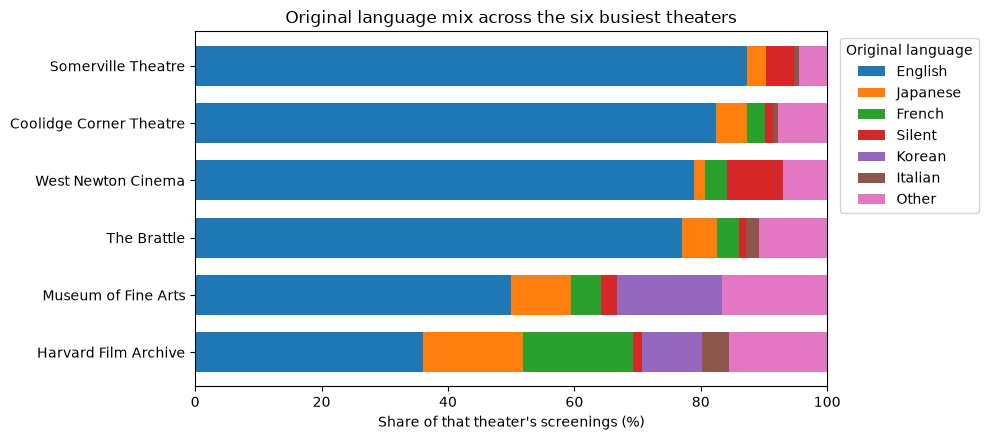

,n,non-English %,languages
theater,,,
The Brattle,797,23.0,27
Coolidge Corner Theatre,658,17.6,22
Harvard Film Archive,283,64.0,17
Somerville Theatre,228,12.7,8
West Newton Cinema,57,21.1,7
Museum of Fine Arts,42,50.0,11


In [29]:
top6 = df["theater"].value_counts().head(6).index
lang = df[df["theater"].isin(top6) & df["language"].notna()].copy()

top_langs = lang["language"].value_counts().head(6).index
lang["lang_grp"] = lang["language"].where(
    lang["language"].isin(top_langs), "Other")

mix = pd.crosstab(
    lang["theater"],
    lang["lang_grp"],
    normalize="index") * 100
mix = mix[list(top_langs) + ["Other"]]
mix = mix.sort_values("English")
mix.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 4.5),
    width=0.7)

plt.xlim(0, 100)
plt.xlabel("Share of that theater's screenings (%)")
plt.ylabel("")
plt.title("Original language mix across the six busiest theaters")
plt.legend(title="Original language", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "n": lang.groupby("theater").size(),
    "non-English %": lang.groupby("theater")["language"].apply(
        lambda x: (x != "English").mean() * 100
    ),
    "languages": lang.groupby("theater")["language"].nunique()
})

summary = summary.loc[top6].round(1)
summary


**Question.** How does original-language programming differ across Boston’s six busiest theaters?

This is interesting because theaters may distinguish themselves not only by the age or type of films they show, but also by the languages represented in their programming.

I restricted the analysis to screenings with a resolved Wikipedia language and compared each theater using a 100%-stacked bar chart. Percentages are normalized within theater so differences in screening volume do not dominate the comparison.

The results show substantial variation. Harvard Film Archive and the Museum of Fine Arts have the highest non-English shares, at 64.0% and 50.0%, while Somerville is the most English-dominant at 12.7% non-English. The Brattle has a lower non-English share of 23.0% but spans 27 distinct languages, suggesting that language breadth and non-English volume capture different aspects of programming.

In [30]:
df.drop(columns=["film_key"]).to_csv("data/movies_enriched.csv", index=False)
print(f"{os.path.getsize('data/movies_enriched.csv')/1e6:.2f} MB, "
      f"{len(df)} rows, {df.shape[1]-1} columns")

0.32 MB, 2400 rows, 12 columns


In [31]:
grader.check("q8")

q8 results: All test cases passed!

### 8a. SQL — AC209A only (3 pts)

The DataFrame operations you've used all assignment — subset, aggregate, join, transform — are the same four verbs SQL speaks, and SQL is the dialect most of industry says them in (see the *DuckDB: SQL on files* supplemental). Pose one Q5-style analytical question about your enriched screening data and answer it with a **single SQL query** run via `duckdb` directly against `data/movies_enriched.csv`. Display the result and interpret it in 2–3 sentences. Prefer a question where SQL earns its keep (a grouped ranking, a window function, a multi-way aggregation).

In [32]:
import duckdb

QUERY = """
WITH cell AS (
    SELECT theater, genre,
           COUNT(*) AS screenings,
           SUM(COUNT(*)) OVER (PARTITION BY theater) AS venue_total,
           ROUND(100.0 * COUNT(*) FILTER (WHERE language IS NOT NULL AND language <> 'English')
                       / NULLIF(COUNT(*) FILTER (WHERE language IS NOT NULL), 0), 1)
               AS pct_non_english
    FROM read_csv_auto('data/movies_enriched.csv')
    WHERE genre IS NOT NULL
    GROUP BY theater, genre
)
SELECT theater,
       genre,
       screenings,
       ROUND(100.0 * screenings / venue_total, 1)                              AS pct_of_venue,
       ROUND(100.0 * screenings / SUM(screenings) OVER (PARTITION BY genre), 1) AS pct_of_market,
       pct_non_english,
       RANK() OVER (PARTITION BY theater ORDER BY screenings DESC)              AS rk
FROM cell
WHERE venue_total >= 150          -- the four major venues
QUALIFY rk <= 4                   -- top 4 genres within each venue
ORDER BY theater, rk;
"""

print(duckdb.sql(QUERY).df())


                    theater        genre  screenings  pct_of_venue  \
0   Coolidge Corner Theatre        Drama         147          21.1   
1   Coolidge Corner Theatre       Comedy         120          17.2   
2   Coolidge Corner Theatre       Horror         110          15.8   
3   Coolidge Corner Theatre       Action          72          10.3   
4      Harvard Film Archive        Drama         191          53.2   
5      Harvard Film Archive  Documentary          55          15.3   
6      Harvard Film Archive       Comedy          28           7.8   
7      Harvard Film Archive        Crime          21           5.8   
8        Somerville Theatre        Drama          49          20.3   
9        Somerville Theatre       Comedy          42          17.4   
10       Somerville Theatre       Horror          37          15.4   
11       Somerville Theatre       Action          23           9.5   
12              The Brattle        Drama         281          32.3   
13              The 

The four major theaters show noticeably different programming profiles. Harvard Film Archive is the most specialized, with Drama making up 53.2% of its screenings and with a high share of non-English films across its leading genres, while Coolidge Corner Theatre and Somerville Theatre have more balanced genre mixes. The Brattle also plays a particularly large role among these venues, accounting for roughly 42%–47% of the screenings in several major genres such as Drama, Comedy, Horror, and Crime.


## Question 9: The decision — program Halloween weekend

<p>You now advise a consortium of the <b>four theaters with the most screenings</b> in your data. They want a coordinated plan for <b>Halloween weekend 2026 (Fri Oct 30 – Sun Nov 1)</b>: each theater programs a small slate, with the goal of maximizing <b>total ticket revenue across the consortium</b> — so the theaters should draw large audiences <i>without competing head-to-head for the same one</i>.</p>

Produce a recommendation, supported by your data. There is no single right answer; you are graded on the clarity of your reasoning and on whether the data you present actually supports the recommendation you make.

### 9.1 Theater personalities

**Identify the four theaters** and characterize their programming "personalities" (the audience each one's history suggests it draws): genre mix, film vintage, language profile — whatever you judge informative. **Profile at least two theaters in depth** (all four encouraged), with at least one supporting visualization.

In [33]:
TOP4 = df["theater"].value_counts().head(4).index.tolist()
d4 = df[df["theater"].isin(TOP4)]

st = df.assign(t=df["screen_times"].fillna("").str.split(",")).explode("t")
st["hour"] = pd.to_datetime(st["t"].str.strip(), format="%I:%M %p", errors="coerce").dt.hour
st4 = st[st["theater"].isin(TOP4)]

profile = pd.DataFrame({
    "screenings":     d4.groupby("theater").size(),
    "median_year":    d4.groupby("theater")["year"].median(),
    "pct_horror":     d4.groupby("theater")["genre"].apply(lambda s: 100 * s.eq("Horror").mean()),
    "pct_nonEnglish": d4.groupby("theater")["language"].apply(lambda s: 100 * s.dropna().ne("English").mean()),
    "languages":      d4.groupby("theater")["language"].nunique(),
    "pct_late_night": st4.groupby("theater")["hour"].apply(lambda h: 100 * ((h >= 22) | (h < 4)).mean()),
}).loc[TOP4].round(1)

print(profile.to_string())

oct25 = df[(df["screen_date"] >= "2025-10-01") & (df["screen_date"] <= "2025-11-02")]
print("\nHorror share, October 2025 vs all-time:")
print(oct25[oct25["theater"].isin(TOP4)].groupby("theater")["genre"]
      .apply(lambda s: 100 * s.eq("Horror").mean()).round(1).loc[TOP4].to_string())


                         screenings  median_year  pct_horror  pct_nonEnglish  languages  pct_late_night
theater                                                                                                
The Brattle                     871       1987.0        12.2            23.0         27             1.7
Coolidge Corner Theatre         697       1992.0        15.8            17.6         22            30.4
Harvard Film Archive            359       1969.0         0.6            64.0         17             0.0
Somerville Theatre              241       1983.0        15.4            12.7          8            10.1

Horror share, October 2025 vs all-time:
theater
The Brattle                26.1
Coolidge Corner Theatre    46.9
Harvard Film Archive        0.0
Somerville Theatre         27.3


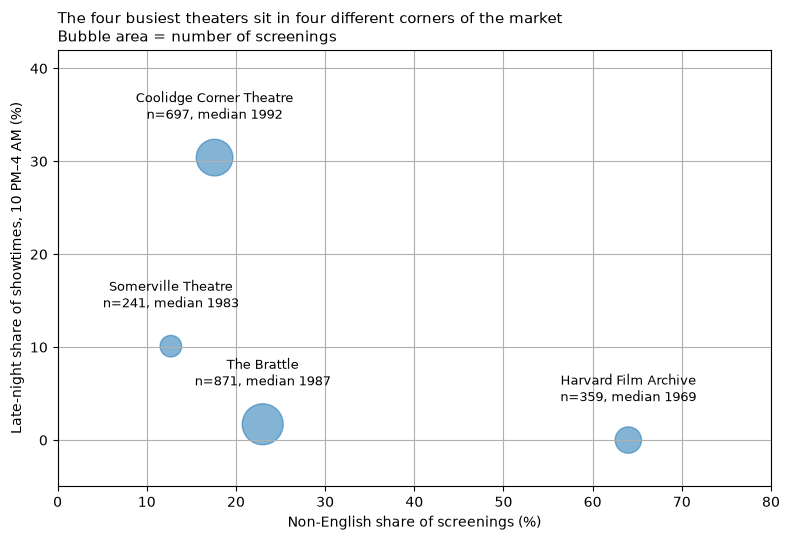

In [34]:
plt.figure(figsize=(8, 5.5))
plt.scatter(
    profile["pct_nonEnglish"],
    profile["pct_late_night"],
    s=profile["screenings"],
    alpha=0.55)
for theater, r in profile.iterrows():
    plt.annotate(
        f"{theater}\nn={r['screenings']:.0f}, median {r['median_year']:.0f}",
        (r["pct_nonEnglish"], r["pct_late_night"]),
        xytext=(0, 28),
        textcoords="offset points",
        ha="center",
        fontsize=9)

plt.xlim(0, 80)
plt.ylim(-5, 42)
plt.xlabel("Non-English share of screenings (%)")
plt.ylabel("Late-night share of showtimes, 10 PM–4 AM (%)")
plt.title(
    "The four busiest theaters sit in four different corners of the market\n"
    "Bubble area = number of screenings",
    loc="left",
    fontsize=11)

plt.grid()
plt.tight_layout()
plt.show()

In [35]:
hw25 = df[(df["screen_date"] >= "2025-10-31") & (df["screen_date"] <= "2025-11-02")]
print(hw25[hw25["theater"].isin(TOP4)][["screen_date", "theater", "title", "genre", "screen_times"]]
      .sort_values(["theater", "screen_date"]).to_string(index=False))

screen_date                 theater                                  title       genre screen_times
 2025-10-31 Coolidge Corner Theatre                              Halloween      Horror     11:59 PM
 2025-11-01 Coolidge Corner Theatre                              Fairyland       Drama      2:00 PM
 2025-11-01 Coolidge Corner Theatre                           Halloween II      Horror     11:59 PM
 2025-11-02 Coolidge Corner Theatre                        6-A Akash Ganga Documentary      2:00 PM
 2025-10-31    Harvard Film Archive                        Ginza Cosmetics       Drama      7:00 PM
 2025-10-31    Harvard Film Archive                       The Song Lantern       Drama      9:00 PM
 2025-11-01    Harvard Film Archive        Learn from Experience, Part One       Drama      7:00 PM
 2025-11-01    Harvard Film Archive        Learn from Experience, Part Two       Drama      8:45 PM
 2025-11-02    Harvard Film Archive                              Our Sunhi     Romance      3:00 PM


### 9.2 Your draw proxy

You have no revenue data, so state explicitly what you will use as a stand-in for "how many people a film/genre draws at this theater" and defend it in a sentence or two.

In [36]:
bookings = (df.groupby(["theater", "title"])
              .agg(dates=("screen_date", "nunique"))
              .reset_index())

print("Repeat-booking behaviour:")
print(bookings[bookings["theater"].isin(TOP4)].groupby("theater")
      .agg(titles=("title", "size"),
           pct_booked_twice=("dates", lambda d: 100 * (d > 1).mean()),
           max_dates=("dates", "max"))
      .loc[TOP4].round(1).to_string())

for t in TOP4:
    print(f"\nTop draws -- {t}")
    print(bookings[bookings["theater"] == t].nlargest(5, "dates")[["title", "dates"]]
          .to_string(index=False))

print("\nBest-performing horror in this market (any venue):")
print(df[df["genre"] == "Horror"].groupby("title")
      .agg(dates=("screen_date", "nunique"), venues=("theater", "nunique"))
      .nlargest(10, "dates").to_string())


Repeat-booking behaviour:
                         titles  pct_booked_twice  max_dates
theater                                                     
The Brattle                 621              25.8          6
Coolidge Corner Theatre     618               8.6          8
Harvard Film Archive        294              21.1          4
Somerville Theatre          215               8.8          4

Top draws -- The Brattle
            title  dates
           Brazil      6
          Charade      6
             Jaws      6
Stop Making Sense      6
            Yi Yi      6

Top draws -- Coolidge Corner Theatre
                     title  dates
                  The Room      8
                Eraserhead      7
                     Akira      4
                      Jaws      4
The Muppet Christmas Carol      4

Top draws -- Harvard Film Archive
                                          title  dates
                                  The Third Man      4
                                Floating Clou

Since I do not have ticket sales or attendance data, I use repeat booking across different dates as my proxy for audience draw. If a theater chooses to show the same film on multiple dates, I treat that as evidence that the theater expects continued audience demand, although this is only an indirect measure because programming decisions can also reflect curatorial preferences.

### 9.3 The slates

Recommend **2–3 films (or film types)** for each theater you profiled, and at least a one-line programming direction for the others. Justify choices with your profiles and draw proxy, and explain how the slates avoid cannibalizing each other.


Coolidge Corner Theatre: I would focus most strongly on recognizable late-night horror, such as Eraserhead, The Shining, or another classic horror title. The horror accounts for 15.8% of its overall screenings but rises to 46.9% in October 2025, and 30.4% of its showtimes are late-night. Eraserhead is also one of its most repeatedly booked films, appearing on seven different dates. This makes Coolidge the natural venue for the traditional midnight-horror audience.

The Brattle: I would program a broader set of classic or cult films, such as Jaws, Brazil, and a gothic or horror-adjacent classic. The Brattle has the largest number of screenings in the dataset and a relatively older median film year of 1987. It also repeatedly booked Jaws and Brazil on six dates each. Its October horror share rises to 26.1%, so Halloween programming fits the theater, but its very low late-night share of 1.7% suggests that matinee or evening screenings would differentiate it from Coolidge's midnight programming.

Harvard Film Archive: I would avoid mainstream Halloween horror and instead program international, older, or art-house films with darker or supernatural themes, such as Japanese ghost cinema or another foreign-language archival program. 65.7% of its screenings are non-English, its median film year is 1969, and only 0.6% of its historical programming is classified as horror. A film such as Kwaidan, which appears on six dates across the market, could fit this audience much better than a conventional slasher film.

Somerville Theatre: I would lean into cult and participatory Halloween entertainment, especially The Rocky Horror Picture Show, along with one or two accessible cult or science-fiction films. Rocky Horror is Somerville's most repeatedly booked title, appearing on four different dates, and the theater actually screened it on Halloween 2025. Somerville also has a 15.4% overall horror share and a 27.3% October horror share, suggesting that Halloween programming already fits its audience.


### 9.4 Uncertainties

At least two ways this analysis could mislead the consortium, and what data you'd want next.

First limitation is that repeat booking is not the same as actual audience demand. A film may be shown many times because a programmer likes it, because of a special series, or because distribution rights make it easy to book. To measure draw more directly, I would want ticket sales, attendance, theater capacity, occupancy rate, and ticket price for each screening.

The second limitation is that the dataset records screenings but does not capture important differences in showtime, auditorium size, and number of seats. A film shown once in a large sold-out auditorium could generate more revenue than a film shown several times in a small room. Capacity and screening-level revenue data would therefore improve both the draw proxy and the final programming recommendation.

## Question 10: Reproducibility reflection, AI disclosure & data submission

### 10.1 Reproducibility reflection

A short paragraph or bullets: walk through your pipeline and identify what is **reproducible** (same result on every re-run, for anyone) and what is **brittle or non-reproducible** — and how you mitigated each risk. Consider at least: the live fetch (Q1), your HTML parsing (Q2), the Wayback snapshots (Q3), and the Wikipedia lookups & content (Q6–Q8). Also: the raw wiki cache is *deliberately excluded* from your submission (see 10.3) — what does that exclusion mean for the reproducibility of your Q8 columns?

Most of my final pipeline is reproducible because the data used for analysis is cached rather than fetched again on every run. The live ScreenBoston page in Q1 is the exception. It depends on what the website showed when it was first downloaded, although the guarded fetch makes later runs use the same saved HTML. The HTML parser in Q2 is deterministic for a given file, but it is somewhat brittle because it relies on specific HTML elements, CSS classes, and metadata formats. I mitigated this by reporting failed listings instead of silently dropping them and by adding a separate legacy parser when the Wayback archive crossed a site redesign. Q3 is more reproducible because the historical data comes from pinned Wayback snapshots. I cached both the snapshot index and each HTML snapshot, used per-file guards so interrupted downloads can resume, retried throttled requests, and checked that a page contained a plausible number of listings before saving it. For Q6–Q8, Wikipedia is another potential source of non-reproducibility because search results, article contents, and even page structure can change over time. I therefore cached the resolved wiki_id values and the derived wiki_meta.csv, and verified the Q8 merge with validate="many_to_one" and a row-count assertion.

Excluded raw wiki cache means another user cannot reproduce the extraction process itself from the original cached Wikipedia wikitext while completely offline. However, the extracted Q8 values are preserved in the submitted wiki_meta.csv and movies_enriched.csv, so the Q8 analysis and columns remain reproducible from the submitted derived data. Re-running the extraction from raw Wikipedia pages would require downloading those pages again.

### 10.2 AI disclosure

A few sentences: how you used AI tools on this assignment (which parts, what for) and — the part we grade — **what you did to verify their output** before signing off on it. There is no penalty for extensive AI use; there is a penalty for unverified submission.

I used AI tools as a coding and debugging assistant during this assignment, especially to help simplify and review parts of the scraping/reproducibility workflow, check whether my Q8 analysis satisfied the requirements, and improve the clarity of some written interpretations. I did not treat the generated code or explanations as automatically correct.

I verified the output by running the code myself, inspecting intermediate DataFrames and examples, checking record and missing-value counts, and confirming that cached files were actually reused on later runs. I also restarted and reran the notebook to make sure the final pipeline produced the expected outputs without relying on previously defined variables.

### 10.3 Data submission

Run the provided manifest cell below. You will upload these files with your notebook so it can be re-run and graded *without any network access*. The full set must stay **under 25 MB** — this is why Q7 cached page content to disk instead of stuffing it in the DataFrame.

In [37]:
# --- PROVIDED CELL: submission manifest. Run before submitting; do not edit.
# Your submission = this notebook + every file listed below (data/wiki/ raw
# page cache is deliberately excluded). The set must total <= 25 MB.
SUBMISSION_FILES = sorted(
    glob.glob("data/html/*.html")     # live page + pinned snapshots
    + glob.glob("data/*.json")        # movies.json, wayback manifest, ...
    + glob.glob("data/*.csv")         # your derived caches / enriched table
)

assert SUBMISSION_FILES, "No data files found -- did the pipeline run?"
assert any("movies_enriched" in f for f in SUBMISSION_FILES), \
    "data/movies_enriched.csv is required (Q8)."

total_mb = sum(os.path.getsize(f) for f in SUBMISSION_FILES) / 1e6
for f in SUBMISSION_FILES:
    print(f"{os.path.getsize(f)/1e6:8.2f} MB  {f}")
print(f"{'-'*40}\n{total_mb:8.2f} MB  total ({len(SUBMISSION_FILES)} files)")

assert total_mb <= 25, "Submission exceeds the 25 MB budget!"
print("\nWithin the 25 MB budget -- ready to submit.")

    0.26 MB  data/html/screenboston.html
    0.01 MB  data/html/snapshot_20240328.html
    0.28 MB  data/html/snapshot_20240524.html
    0.17 MB  data/html/snapshot_20240621.html
    0.26 MB  data/html/snapshot_20240803.html
    0.27 MB  data/html/snapshot_20240904.html
    0.40 MB  data/html/snapshot_20240926.html
    0.31 MB  data/html/snapshot_20241006.html
    0.24 MB  data/html/snapshot_20241101.html
    0.17 MB  data/html/snapshot_20241206.html
    0.19 MB  data/html/snapshot_20250105.html
    0.29 MB  data/html/snapshot_20250131.html
    0.20 MB  data/html/snapshot_20250217.html
    0.18 MB  data/html/snapshot_20250326.html
    0.22 MB  data/html/snapshot_20250428.html
    0.20 MB  data/html/snapshot_20250616.html
    0.18 MB  data/html/snapshot_20250622.html
    0.27 MB  data/html/snapshot_20250813.html
    0.33 MB  data/html/snapshot_20250903.html
    0.23 MB  data/html/snapshot_20250924.html
    0.24 MB  data/html/snapshot_20251021.html
    0.26 MB  data/html/snapshot_2025112

In [38]:
grader.check("q10_3")

q10_3 results: All test cases passed!

## Wrap-up

<div class="alert alert-info" style="color: #4a4a4a; background-color: #fbe8ff; border-color: #eed4db; border-width: 1px; border-radius: 3px; padding: 10px;">

* Which aspect(s) of the assignment did you find most challenging — conceptually or in implementation? Any remaining questions?

* How many hours did you spend on this assignment? Store an int or float in `hours_spent_on_hw` (if you worked in a group, report the average per person).

</div>

I found the web scraping portion the most challenging because I was not very familiar with accurate webscraping before this assignment, so learning took most of the time. Also,the problem with the API confused me and I struggled a while.

In [39]:
hours_spent_on_hw = 20

In [40]:
grader.check("wrapup")

wrapup results: All test cases passed!

In [41]:
notebook_end = time.time()
print(f"It took {(notebook_end - notebook_start)/60:.2f} minutes for this notebook to run")

It took 0.09 minutes for this notebook to run


🌈 **This concludes HW1. Thank you!**